In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [31]:
# Load the dataset
data = pd.read_csv('swiggy.csv')
data.head(10)

,ID,Area,City,Restaurant,Price,Avg ratings,Total ratings,Food type,Address,Delivery time
0,211,Koramangala,Bangalore,Tandoor Hut,300.0,4.4,100,"Biryani,Chinese,North Indian,South Indian",5Th Block,59
1,221,Koramangala,Bangalore,Tunday Kababi,300.0,4.1,100,"Mughlai,Lucknowi",5Th Block,56
2,246,Jogupalya,Bangalore,Kim Lee,650.0,4.4,100,Chinese,Double Road,50
3,248,Indiranagar,Bangalore,New Punjabi Hotel,250.0,3.9,500,"North Indian,Punjabi,Tandoor,Chinese",80 Feet Road,57
4,249,Indiranagar,Bangalore,Nh8,350.0,4.0,50,"Rajasthani,Gujarati,North Indian,Snacks,Desser...",80 Feet Road,63
5,254,Indiranagar,Bangalore,Treat,800.0,4.5,100,"Mughlai,North Indian",100 Feet Road,56
6,258,Indiranagar,Bangalore,Chinita Real Mexican Food,1000.0,4.5,500,"Mexican,Beverages,Salads",Double Road,53
7,263,Koramangala,Bangalore,Cupcake Noggins - Cakespastries And Desserts,150.0,4.3,100,"Desserts,British,Bakery,Pizzas,Snacks",4Th Block,57
8,267,Domlur,Bangalore,Tea Brew,350.0,4.1,100,"American,Italian,Beverages,Continental,Chinese...",Double Road,57
9,308,Koramangala,Bangalore,Bangaliana,300.0,4.0,500,Bengali,7Th Block,57


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8680 entries, 0 to 8679
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             8680 non-null   int64  
 1   Area           8680 non-null   object 
 2   City           8680 non-null   object 
 3   Restaurant     8680 non-null   object 
 4   Price          8680 non-null   float64
 5   Avg ratings    8680 non-null   float64
 6   Total ratings  8680 non-null   int64  
 7   Food type      8680 non-null   object 
 8   Address        8680 non-null   object 
 9   Delivery time  8680 non-null   int64  
dtypes: float64(2), int64(3), object(5)
memory usage: 678.3+ KB


In [4]:
data.describe()

,ID,Price,Avg ratings,Total ratings,Delivery time
count,8680.000000,8680.000000,8680.000000,8680.000000,8680.000000
mean,244812.071429,348.444470,3.655104,156.634793,53.967051
std,158671.617188,230.940074,0.647629,391.448014,14.292335
min,211.000000,0.000000,2.000000,20.000000,20.000000
25%,72664.000000,200.000000,2.900000,50.000000,44.000000
50%,283442.000000,300.000000,3.900000,80.000000,53.000000
75%,393425.250000,400.000000,4.200000,100.000000,64.000000
max,466928.000000,2500.000000,5.000000,10000.000000,109.000000


In [5]:
data.isnull().sum()

ID               0
Area             0
City             0
Restaurant       0
Price            0
Avg ratings      0
Total ratings    0
Food type        0
Address          0
Delivery time    0
dtype: int64

In [ ]:
total_price = data['Price'].sum()   # Calculate the total price of all orders
print(total_price)  


3024498.0


In [13]:
# Calculate the average price of orders
average_price = data['Price'].mean()
print(average_price)

348.4444700460829


In [14]:
# Calculate the average price of orders
average_price = data['Price'].mean()
print(average_price)

348.4444700460829


In [19]:
total_AVG_Rating = data['Total ratings'].mean()   # Calculate the average rating of all orders
print(total_AVG_Rating)

156.6347926267281


In [21]:
unique_users = data['ID'].nunique()   # Calculate the number of unique users
print(unique_users)

8680


In [22]:
# unique restaurants
unique_restaurants = data['Restaurant'].nunique()
print(unique_restaurants)

7865


In [ ]:
# Most popular restaurant
most_popular_restaurant = data['Restaurant'].value_counts().idxmax()  #idxmax() returns the index of the first occurrence of the maximum value in the Series, which in this case is the name of the most popular restaurant.
print(most_popular_restaurant)

La Pino'Z Pizza


In [24]:
# unique city 
unique_cities = data['City'].nunique()
print(unique_cities)

9


In [25]:
# most popular city by number of orders
most_popular_city = data['City'].value_counts().idxmax()
print(most_popular_city)


Kolkata


In [26]:
#city which ha the highest average order price
price_city = data.groupby('City')['Price'].mean()  # Group the data by 'City' and calculate the average price for each city
city_with_highest_avg_price = price_city.idxmax()  # Find the city with the highest average price
print(city_with_highest_avg_price)  

Mumbai


In [28]:
# Most popular food item that is ordered
Popular_food = data['Food type'].value_counts().idxmax()
print(Popular_food)

Indian


In [29]:
# min dilivery time
min_delivery_time = data['Delivery time'].min()
print(min_delivery_time)

20


In [30]:
# max delivery time
max_delivery_time = data['Delivery time'].max()
print(max_delivery_time)

109


In [32]:
# Total Areas covered by swiggy
total_areas = data['Area'].nunique()
print(total_areas)

833


In [33]:
# top 3 repiting areas most 
top_3_repeating_areas = data['Area'].value_counts().head(3)
print(top_3_repeating_areas)

Area
Rohini     257
Chembur    208
Kothrud    149
Name: count, dtype: int64


In [34]:
# highest amount order price
highest_order_price = data['Price'].max()
print(highest_order_price)

2500.0


In [35]:
# minimum order price
min_order_price = data['Price'].min()
print(min_order_price)

0.0


In [38]:
# total no. of orders which is less then 30 min delivery time
orders_less_than_30_min = data[data['Delivery time'] < 30].shape[0]  # shape[0] gives the number of rows in the filtered DataFrame
print(orders_less_than_30_min)

154


In [45]:
# adding a new column for delivery performance

data['Delivery Performance'] = pd.cut(data['Delivery time'], bins=[0, 30, 60,100], labels=['Fast', 'Average', 'Slow'], duplicates='drop')
print(data[['Delivery time', 'Delivery Performance']].head(5))

   Delivery time Delivery Performance
0             59              Average
1             56              Average
2             50              Average
3             57              Average
4             63                 Slow


In [ ]:
# Create a new column for price category
data['Price Category'] = pd.cut(data['Price'], bins=[0, 400, 700, 2000], labels=['Low', 'Medium', 'High'])
print(data[['Price', 'Price Category']].head(5))

   Price Price Category
0  300.0            Low
1  300.0            Low
2  650.0         Medium
3  250.0            Low
4  350.0            Low


Visualization 

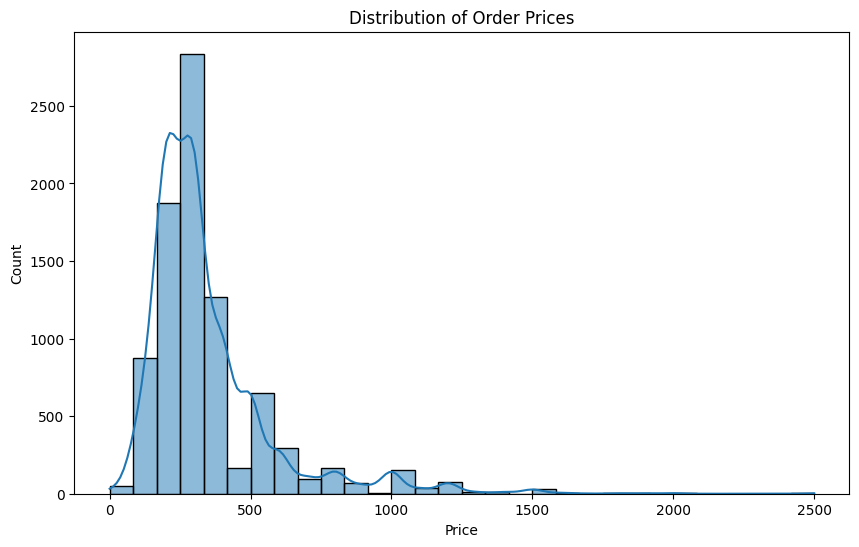

In [52]:
# plot the distribution of order prices
plt.figure(figsize=(10, 6))
sns.histplot(data['Price'], bins=30, kde=True)
plt.title('Distribution of Order Prices')
plt.xlabel('Price')
plt.show()

C:\Users\saini\AppData\Local\Temp\ipykernel_24556\3073909920.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


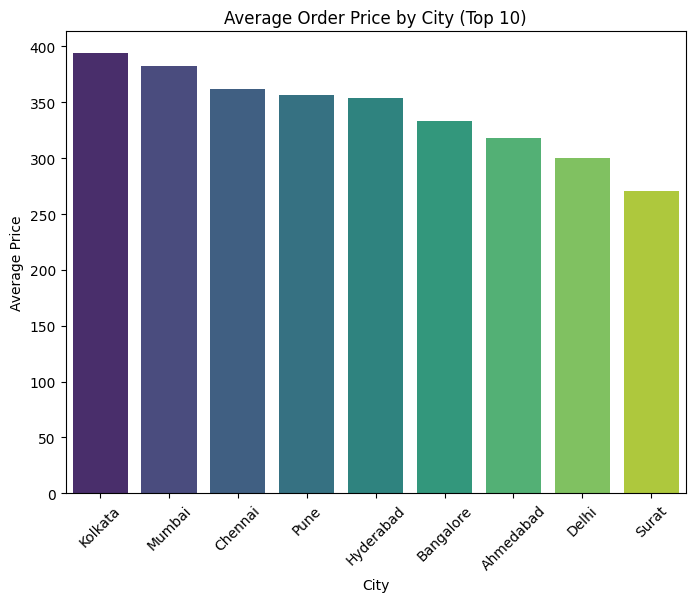

In [59]:
# plot the distribution of city wise average order price   top 10 cities 

plt.figure(figsize=(8, 6))
sns.barplot(
    x=data['City'].value_counts().index[:10],
    y=data.groupby('City')['Price'].mean().sort_values(ascending=False).head(10).values,
    palette='viridis'
)
plt.title('Average Order Price by City (Top 10)')
plt.xlabel('City')
plt.ylabel('Average Price')
plt.xticks(rotation=45)
plt.show()

C:\Users\saini\AppData\Local\Temp\ipykernel_24556\129353727.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_restaurants.index, y=top_10_restaurants.values, palette='magma')


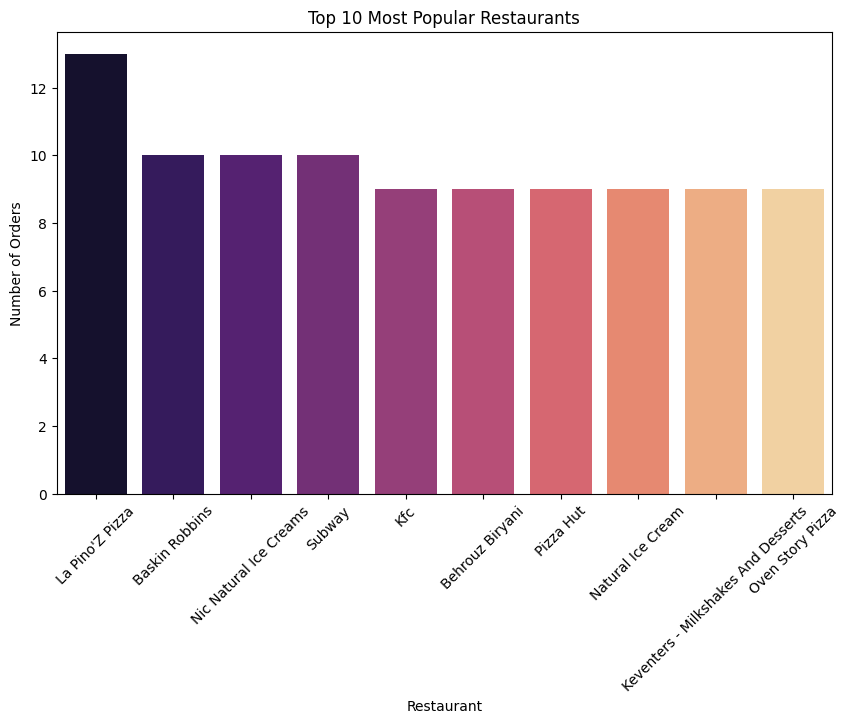

In [60]:
# top 10 most popular restaurants 
top_10_restaurants = data['Restaurant'].value_counts().head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_restaurants.index, y=top_10_restaurants.values, palette='magma')
plt.title('Top 10 Most Popular Restaurants')
plt.xlabel('Restaurant')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.show()

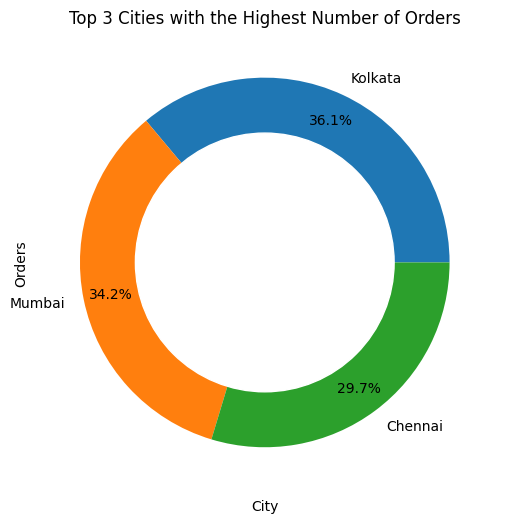

In [68]:
# top 3 cities with the highest number of orders - donut chart
top_3_cities = data['City'].value_counts().head(3)
plt.figure(figsize=(8, 6))
plt.pie(top_3_cities.values, labels=top_3_cities.index, autopct='%1.1f%%', pctdistance=0.85)
plt.gca().add_artist(plt.Circle((0, 0), 0.70, color='white'))  # Add the white circle to the plot
plt.title('Top 3 Cities with the Highest Number of Orders')
plt.xlabel('City')
plt.ylabel('Orders')
plt.show()

In [ ]:
# top 3  users with the highest total order price
top_3_users = data.groupby('ID')['Price'].sum().sort_values(ascending=False).head(3)

# replace top_3 users like user_1, user_2, user_3
top_3_users.index = ['User_1', 'User_2', 'User_3']
print(top_3_users)


User_1    2500.0
User_2    2500.0
User_3    2500.0
Name: Price, dtype: float64


C:\Users\saini\AppData\Local\Temp\ipykernel_24556\4227691965.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_3_users.index, y=top_3_users.values, palette='magma')


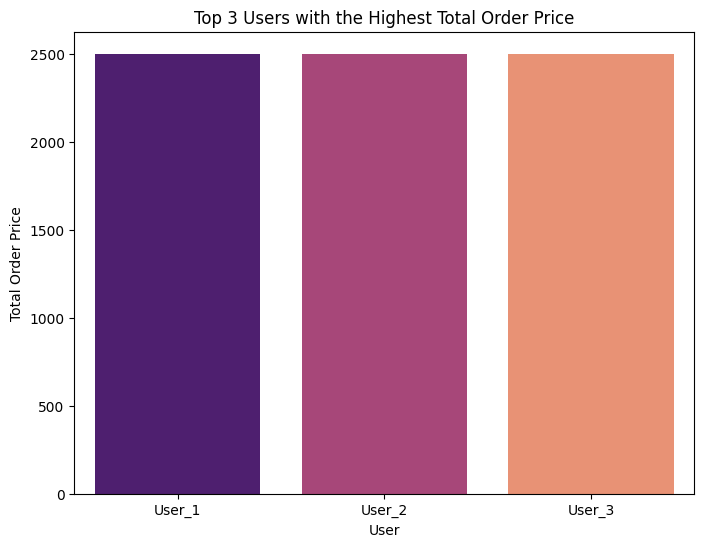

In [73]:
# chart  for top 3 users with the highest total order price
plt.figure(figsize=(8, 6))
sns.barplot(x=top_3_users.index, y=top_3_users.values, palette='magma')
plt.title('Top 3 Users with the Highest Total Order Price')
plt.xlabel('User')
plt.ylabel('Total Order Price')
plt.show()
